# FREIGHT-MNet Paper Figure Generator

This notebook creates paper-ready figures for the FREIGHT-MNet / D-CQHGT KDD manuscript. It is intentionally independent from model training notebooks: it reads consolidated CSV outputs and generates visual summaries for the final paper.

The notebook is designed to be robust to two layouts:

1. Running next to the consolidated CSV files, for example after copying tables to the same folder.
2. Running inside the project tree under `E:\NetworkOptimization\pythonProject1\Data`.

It does not train models and does not require PyTorch Geometric. It only needs `pandas`, `numpy`, and `matplotlib`.


In [1]:

from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Dict, Iterable, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)


Pandas: 2.3.3
NumPy: 2.4.5


## 1. Path configuration

Update `PROJECT_DATA_ROOT` if your project uses a different drive or folder. The notebook first searches the current working directory and `/mnt/data`, then falls back to the Windows project paths used in the FREIGHT-MNet experiments.


In [2]:

PROJECT_DATA_ROOT = Path(r"E:\NetworkOptimization\pythonProject1\Data")
SCOPE = "east_plus_gulf"

LOCAL_CANDIDATE_DIRS = [
    Path.cwd(),
    Path("/mnt/data"),
    PROJECT_DATA_ROOT / "10_experiments" / "final_results_consolidation_v1_notebook" / SCOPE / "tables",
    PROJECT_DATA_ROOT / "10_experiments" / "calibration_cvar_evaluation_v1_notebook" / SCOPE,
    PROJECT_DATA_ROOT / "10_experiments" / "calibration_cvar_evaluation_v1_notebook" / SCOPE / "tables",
]

OUTPUT_DIR = (
    PROJECT_DATA_ROOT / "10_experiments" / "paper_figures_v1" / SCOPE
    if PROJECT_DATA_ROOT.exists()
    else Path.cwd() / "paper_figures_v1" / SCOPE
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)


Output directory: E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf


## 2. Robust CSV loading helpers

The helper below searches all candidate folders for a file name. Missing files are reported, but the notebook continues and produces all figures possible from available inputs.


In [3]:

def find_file(filename: str, extra_dirs: Optional[Sequence[Path]] = None) -> Optional[Path]:
    dirs = list(LOCAL_CANDIDATE_DIRS)
    if extra_dirs:
        dirs.extend(extra_dirs)
    for directory in dirs:
        path = Path(directory) / filename
        if path.exists():
            return path
    return None


def read_csv_optional(filename: str) -> pd.DataFrame:
    path = find_file(filename)
    if path is None:
        print(f"Missing: {filename}")
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        print(f"Loaded {filename}: {df.shape} from {path}")
        return df
    except Exception as exc:
        print(f"Could not read {filename}: {exc}")
        return pd.DataFrame()


def save_figure(fig, name: str) -> None:
    png = OUTPUT_DIR / f"{name}.png"
    pdf = OUTPUT_DIR / f"{name}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved", png)
    print("Saved", pdf)


## 3. Load final tables and segment summaries

The expected final consolidation tables are:

- `table_3_cold_od_main_results.csv`
- `table_4_graph_ablation.csv`
- `table_5_topology_ablation.csv`
- `table_7_calibration_summary.csv`
- `table_8_decision_cvar_screening.csv`

Optional segment summaries improve the q75-decile and sparse-support plots.


In [4]:

table_1 = read_csv_optional("table_1_dataset_summary.csv")
table_2 = read_csv_optional("table_2_temporal_baselines.csv")
table_3 = read_csv_optional("table_3_cold_od_main_results.csv")
table_4 = read_csv_optional("table_4_graph_ablation.csv")
table_5 = read_csv_optional("table_5_topology_ablation.csv")
table_7 = read_csv_optional("table_7_calibration_summary.csv")
table_8 = read_csv_optional("table_8_decision_cvar_screening.csv")

q75_segment = read_csv_optional("calibrated_selected_segment_summary__true_q75_decile.csv")
iqr_segment = read_csv_optional("calibrated_selected_segment_summary__true_iqr_decile.csv")
sparse_segment = read_csv_optional("calibrated_selected_segment_summary__n_fmi_county_pairs_quartile.csv")
repaired_sparse_audit = read_csv_optional("repaired_sparse_segment_audit.csv")


Loaded table_1_dataset_summary.csv: (10, 2) from E:\NetworkOptimization\pythonProject1\Data\10_experiments\final_results_consolidation_v1_notebook\east_plus_gulf\tables\table_1_dataset_summary.csv
Loaded table_2_temporal_baselines.csv: (6, 78) from E:\NetworkOptimization\pythonProject1\Data\10_experiments\final_results_consolidation_v1_notebook\east_plus_gulf\tables\table_2_temporal_baselines.csv
Loaded table_3_cold_od_main_results.csv: (5, 78) from E:\NetworkOptimization\pythonProject1\Data\10_experiments\final_results_consolidation_v1_notebook\east_plus_gulf\tables\table_3_cold_od_main_results.csv
Loaded table_4_graph_ablation.csv: (8, 78) from E:\NetworkOptimization\pythonProject1\Data\10_experiments\final_results_consolidation_v1_notebook\east_plus_gulf\tables\table_4_graph_ablation.csv
Loaded table_5_topology_ablation.csv: (9, 78) from E:\NetworkOptimization\pythonProject1\Data\10_experiments\final_results_consolidation_v1_notebook\east_plus_gulf\tables\table_5_topology_ablation.c

## 4. Figure 1: Method and evidence storyline

This schematic is meant for the paper introduction or method overview. It visually summarizes the complete chain: public data integration, OD-year quantile task, graph models, topology/disruption modules, and decision-aware evaluation.


Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_1_storyline_pipeline.png
Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_1_storyline_pipeline.pdf


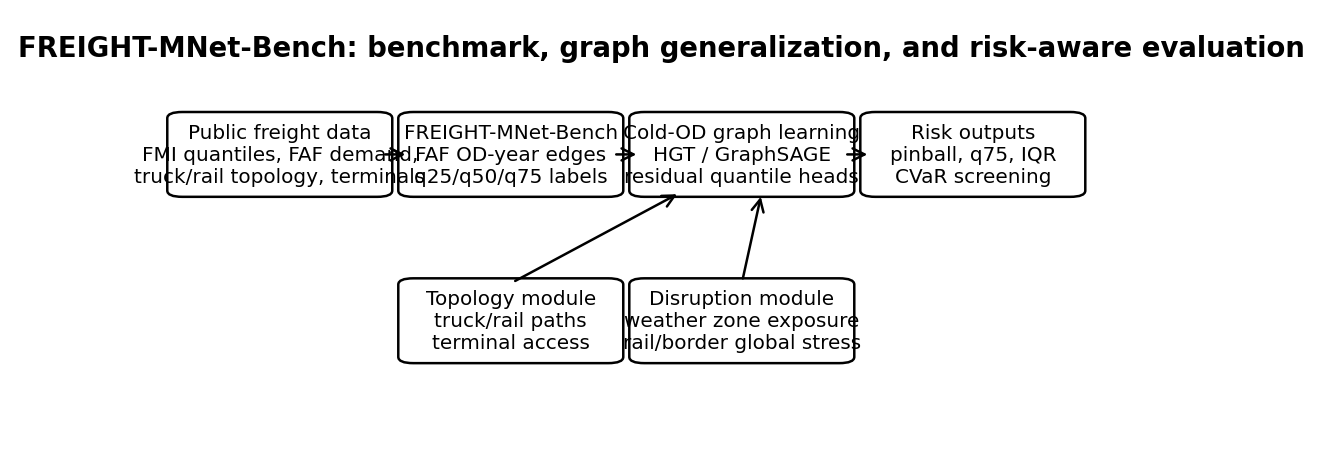

In [5]:

def add_box(ax, xy, text, width=0.18, height=0.13):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.012,rounding_size=0.015",
        linewidth=1.0,
        edgecolor="black",
        facecolor="white",
    )
    ax.add_patch(patch)
    ax.text(x + width/2, y + height/2, text, ha="center", va="center", wrap=True, fontsize=8)
    return patch


def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=12, linewidth=1.0, color="black")
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ax.set_axis_off()

boxes = [
    ((0.02, 0.58), "Public freight data\nFMI quantiles, FAF demand,\ntruck/rail topology, terminals"),
    ((0.25, 0.58), "FREIGHT-MNet-Bench\nFAF OD-year edges\nq25/q50/q75 labels"),
    ((0.48, 0.58), "Cold-OD graph learning\nHGT / GraphSAGE\nresidual quantile heads"),
    ((0.71, 0.58), "Risk outputs\npinball, q75, IQR\nCVaR screening"),
    ((0.25, 0.18), "Topology module\ntruck/rail paths\nterminal access"),
    ((0.48, 0.18), "Disruption module\nweather zone exposure\nrail/border global stress"),
]
for xy, text in boxes:
    add_box(ax, xy, text, width=0.20, height=0.18)

add_arrow(ax, (0.22, 0.67), (0.25, 0.67))
add_arrow(ax, (0.45, 0.67), (0.48, 0.67))
add_arrow(ax, (0.68, 0.67), (0.71, 0.67))
add_arrow(ax, (0.35, 0.36), (0.52, 0.58))
add_arrow(ax, (0.58, 0.36), (0.60, 0.58))

ax.text(0.5, 0.96, "FREIGHT-MNet-Bench: benchmark, graph generalization, and risk-aware evaluation", ha="center", va="top", fontsize=11, fontweight="bold")

save_figure(fig, "fig_1_storyline_pipeline")
plt.show()


## 5. Figure 2: Cold-OD main results

This figure emphasizes the primary empirical contribution: graph models sharply improve Cold-OD unseen-relation prediction compared with the non-graph MLP baseline.


Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_2_cold_od_pinball_main.png
Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_2_cold_od_pinball_main.pdf


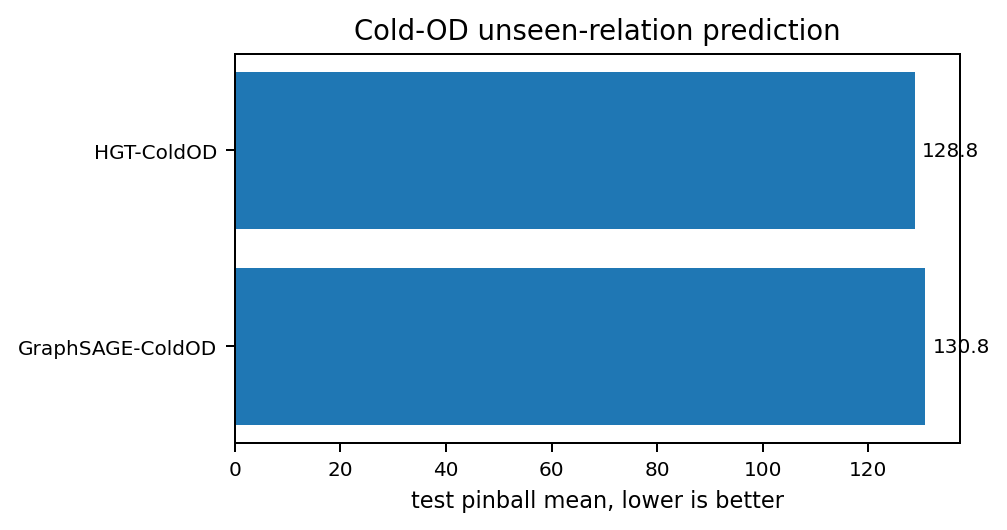

In [6]:

def choose_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

if not table_3.empty:
    df = table_3.copy()
    model_col = choose_col(df, ["paper_model", "model", "Model"])
    pin_col = choose_col(df, ["pinball_mean", "Pinball", "pinball"])
    q75_col = choose_col(df, ["mae_q75", "q75 MAE", "q75"])
    iqr_col = choose_col(df, ["iqr_mae", "IQR MAE", "iqr"])
    keep_models = ["HGT-ColdOD", "GraphSAGE-ColdOD", "ColdOD-MLP"]
    if model_col and pin_col:
        df[model_col] = df[model_col].astype(str)
        sub = df[df[model_col].isin(keep_models)].copy()
        if sub.empty:
            sub = df.sort_values(pin_col).head(5).copy()
        sub = sub.sort_values(pin_col, ascending=True)
        fig, ax = plt.subplots(figsize=(5.2, 2.8))
        ax.barh(sub[model_col], sub[pin_col])
        ax.set_xlabel("test pinball mean, lower is better")
        ax.set_title("Cold-OD unseen-relation prediction")
        ax.invert_yaxis()
        for i, v in enumerate(sub[pin_col]):
            ax.text(v + max(sub[pin_col]) * 0.01, i, f"{v:.1f}", va="center", fontsize=8)
        save_figure(fig, "fig_2_cold_od_pinball_main")
        plt.show()
else:
    print("table_3 is missing; skipped Figure 2.")


## 6. Figure 3: Main metric comparison across model roles

This figure compares HGT, GraphSAGE, and ColdOD-MLP on pinball, q75 MAE, and IQR MAE. It is useful for explaining why HGT and GraphSAGE have different roles.


Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_3_cold_od_metric_roles.png
Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_3_cold_od_metric_roles.pdf


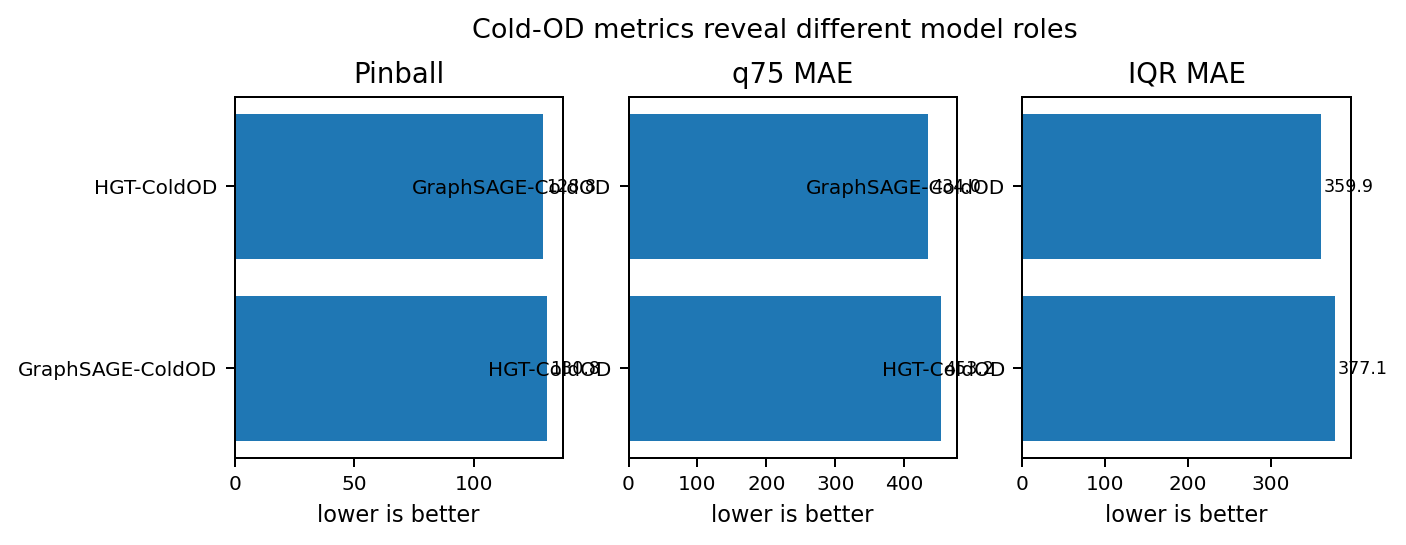

In [7]:

if not table_3.empty:
    df = table_3.copy()
    model_col = choose_col(df, ["paper_model", "model", "Model"])
    cols = {
        "Pinball": choose_col(df, ["pinball_mean", "Pinball", "pinball"]),
        "q75 MAE": choose_col(df, ["mae_q75", "q75 MAE", "q75"]),
        "IQR MAE": choose_col(df, ["iqr_mae", "IQR MAE", "iqr"]),
    }
    keep_models = ["HGT-ColdOD", "GraphSAGE-ColdOD", "ColdOD-MLP"]
    sub = df[df[model_col].astype(str).isin(keep_models)].copy()
    sub = sub.set_index(model_col)
    plot_data = pd.DataFrame({name: sub[col] for name, col in cols.items() if col is not None})
    plot_data = plot_data.loc[[m for m in keep_models if m in plot_data.index]]
    fig, axes = plt.subplots(1, len(plot_data.columns), figsize=(8.0, 2.6))
    if len(plot_data.columns) == 1:
        axes = [axes]
    for ax, metric in zip(axes, plot_data.columns):
        vals = plot_data[metric].sort_values(ascending=True)
        ax.barh(vals.index, vals.values)
        ax.set_title(metric)
        ax.invert_yaxis()
        ax.set_xlabel("lower is better")
        for i, v in enumerate(vals.values):
            ax.text(v + max(vals.values)*0.01, i, f"{v:.1f}", va="center", fontsize=7)
    fig.suptitle("Cold-OD metrics reveal different model roles", y=1.05)
    save_figure(fig, "fig_3_cold_od_metric_roles")
    plt.show()
else:
    print("table_3 is missing; skipped Figure 3.")


## 7. Figure 4: Topology/disruption slice contribution

This figure summarizes selected topology/disruption variants across stress and sparse q75 metrics. It supports the narrative that topology/weather modules are targeted robustness signals rather than universal winners.


Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_4_topology_targeted_slices.png
Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_4_topology_targeted_slices.pdf


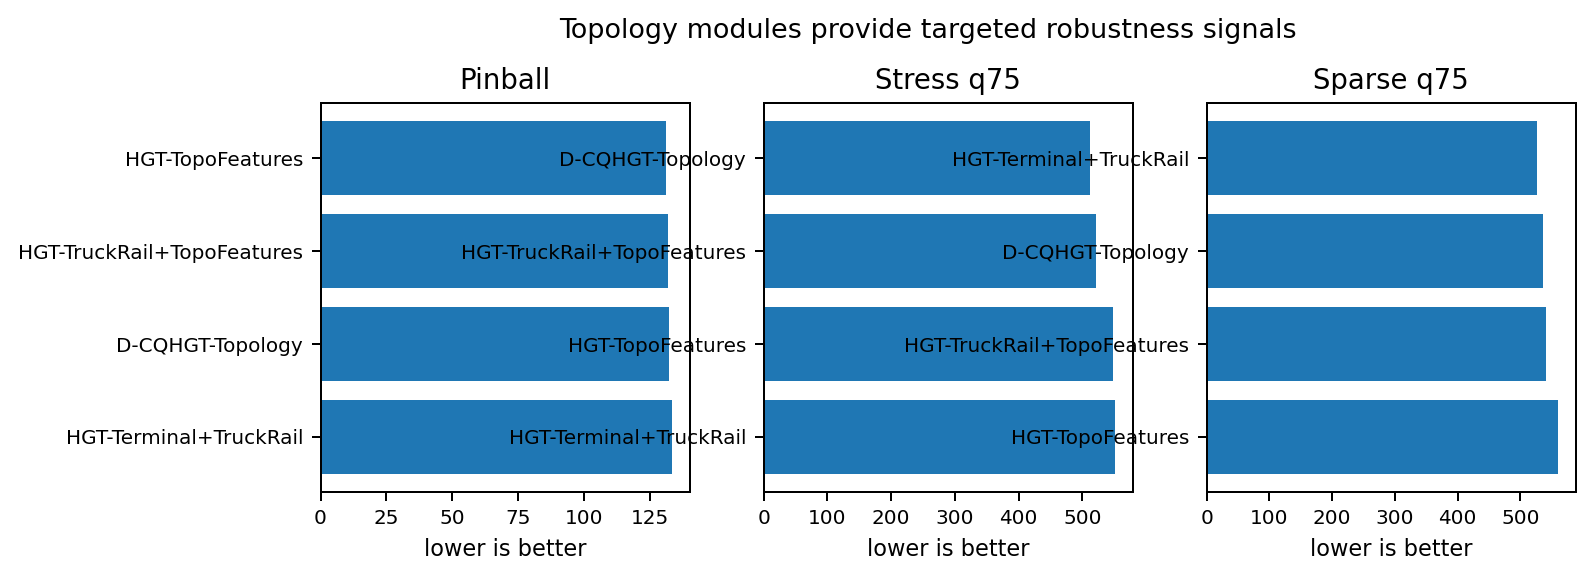

In [8]:

if not table_5.empty:
    df = table_5.copy()
    model_col = choose_col(df, ["paper_model", "model", "Model"])
    stress_col = choose_col(df, ["stress_top10_mae_q75", "Stress q75", "stress_q75"])
    sparse_col = choose_col(df, ["sparse_bottom25_mae_q75", "Sparse q75", "sparse_q75"])
    pin_col = choose_col(df, ["pinball_mean", "Pinball", "pinball"])
    cols = [("Pinball", pin_col), ("Stress q75", stress_col), ("Sparse q75", sparse_col)]
    cols = [(n, c) for n, c in cols if c is not None]
    if model_col and cols:
        show = [
            "HGT-TopoFeatures",
            "HGT-TruckRail+TopoFeatures",
            "D-CQHGT-Topology",
            "HGT-Terminal+TruckRail",
            "FAF-HGT no topology",
        ]
        sub = df[df[model_col].astype(str).isin(show)].copy()
        if sub.empty:
            sub = df.sort_values(cols[0][1]).head(6).copy()
        sub = sub.set_index(model_col)
        fig, axes = plt.subplots(1, len(cols), figsize=(9.0, 2.8))
        if len(cols) == 1:
            axes = [axes]
        for ax, (name, col) in zip(axes, cols):
            vals = sub[col].sort_values(ascending=True)
            ax.barh(vals.index, vals.values)
            ax.set_title(name)
            ax.set_xlabel("lower is better")
            ax.invert_yaxis()
        fig.suptitle("Topology modules provide targeted robustness signals", y=1.05)
        save_figure(fig, "fig_4_topology_targeted_slices")
        plt.show()
else:
    print("table_5 is missing; skipped Figure 4.")


## 8. Figure 5: Decision-aware CVaR screening regret

This figure should be used in the paper's decision-aware evaluation subsection. It focuses on normalized regret because it is scale-free and easy to compare.


Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_5_cvar_screening_regret.png
Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_5_cvar_screening_regret.pdf


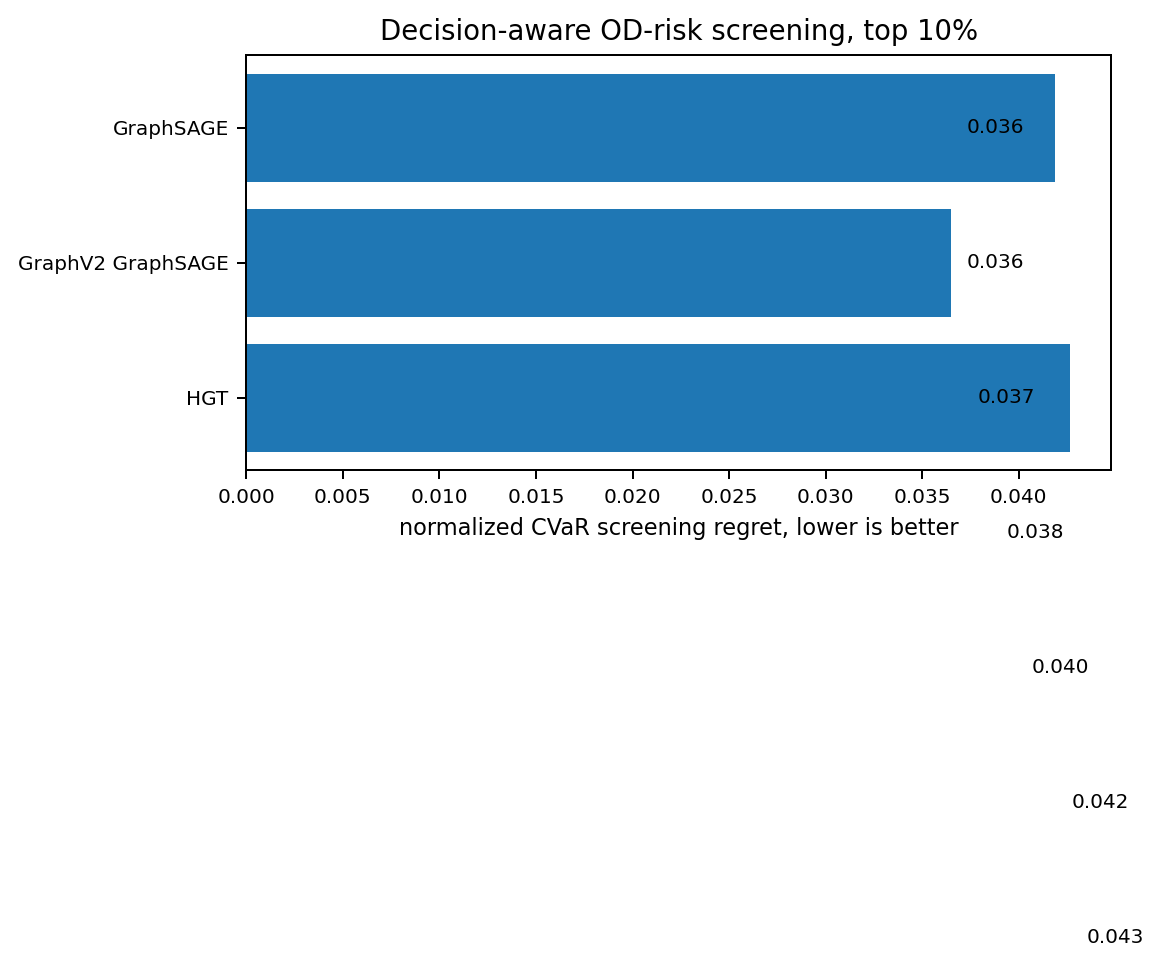

In [9]:

if not table_8.empty:
    df = table_8.copy()
    model_col = choose_col(df, ["paper_model", "model", "Model"])
    regret_col = choose_col(df, ["normalized_cvar_regret", "normalized_cvar_regret_top10", "N-Reg."])
    if model_col and regret_col:
        df[model_col] = df[model_col].astype(str)
        sub = df.sort_values(regret_col, ascending=True).head(7).copy()
        # Shorten labels for plotting.
        label_map = {
            "graphsage_residual_prior_features": "GraphSAGE",
            "graphv2_graphsage": "GraphV2 GraphSAGE",
            "hgt_residual_prior_features": "HGT",
            "graphv2_hgt": "GraphV2 HGT",
        }
        labels = []
        for value in sub[model_col]:
            short = str(value)
            for key, mapped in label_map.items():
                if key.lower() in short.lower():
                    short = mapped
                    break
            labels.append(short)
        sub["plot_label"] = labels
        fig, ax = plt.subplots(figsize=(6.2, 3.0))
        ax.barh(sub["plot_label"], sub[regret_col])
        ax.set_xlabel("normalized CVaR screening regret, lower is better")
        ax.set_title("Decision-aware OD-risk screening, top 10%")
        ax.invert_yaxis()
        for i, v in enumerate(sub[regret_col]):
            ax.text(v + max(sub[regret_col]) * 0.02, i, f"{v:.3f}", va="center", fontsize=8)
        save_figure(fig, "fig_5_cvar_screening_regret")
        plt.show()
else:
    print("table_8 is missing; skipped Figure 5.")


## 9. Figure 6: q75 decile diagnostic for selected models

This plot is optional for the main paper and useful for the appendix. It shows whether a model's q75 error is concentrated in high-risk deciles.


Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_6_q75_decile_diagnostic.png
Saved E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_6_q75_decile_diagnostic.pdf


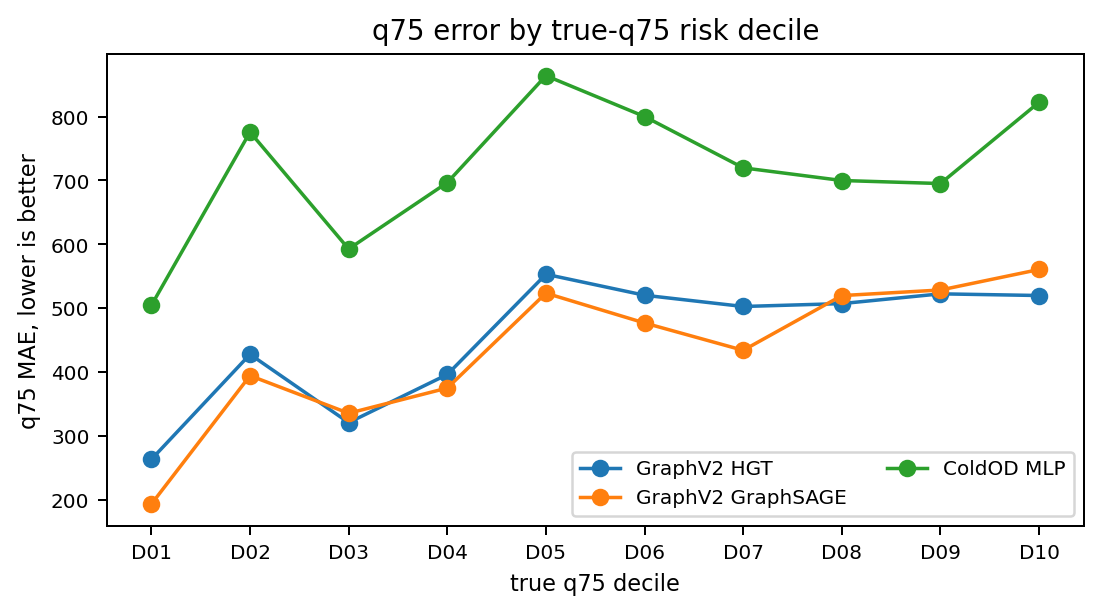

In [10]:

def simplify_model_label(row: pd.Series) -> str:
    text = "::".join(str(row.get(c, "")) for c in ["source", "model", "calibration_method"] if c in row.index)
    low = text.lower()
    if "graphv2_hgt" in low or ("hgt_residual" in low and "reference" in low):
        return "GraphV2 HGT"
    if "graphv2_graphsage" in low or ("graphsage" in low and "reference" in low):
        return "GraphV2 GraphSAGE"
    if "terminal_plus_truck_plus_rail" in low and "weather" in low:
        return "Topo+Weather"
    if "truck_rail_plus_topology" in low and "weather" in low:
        return "TruckRail+Topo+Weather"
    if "mlp" in low:
        return "ColdOD MLP"
    return str(row.get("model", "model"))[:30]

if not q75_segment.empty:
    df = q75_segment.copy()
    seg_col = choose_col(df, ["true_q75_decile"])
    metric_col = choose_col(df, ["mae_q75", "q75 MAE", "q75"])
    if seg_col and metric_col:
        df["plot_model"] = df.apply(simplify_model_label, axis=1)
        keep = ["GraphV2 HGT", "GraphV2 GraphSAGE", "Topo+Weather", "TruckRail+Topo+Weather", "ColdOD MLP"]
        sub = df[df["plot_model"].isin(keep)].copy()
        # Keep one row per model and decile by taking the best available q75 metric.
        sub = sub.sort_values(metric_col).drop_duplicates(["plot_model", seg_col], keep="first")
        if not sub.empty:
            order = sorted(sub[seg_col].dropna().unique())
            fig, ax = plt.subplots(figsize=(7.0, 3.4))
            for model in keep:
                tmp = sub[sub["plot_model"].eq(model)].set_index(seg_col).reindex(order)
                if tmp[metric_col].notna().sum() > 0:
                    ax.plot(range(len(order)), tmp[metric_col].values, marker="o", linewidth=1.4, label=model)
            ax.set_xticks(range(len(order)))
            ax.set_xticklabels([str(x).replace("true_q75_decile_", "D") for x in order], rotation=0)
            ax.set_ylabel("q75 MAE, lower is better")
            ax.set_xlabel("true q75 decile")
            ax.set_title("q75 error by true-q75 risk decile")
            ax.legend(frameon=True, ncol=2)
            save_figure(fig, "fig_6_q75_decile_diagnostic")
            plt.show()
else:
    print("q75 segment summary is missing; skipped Figure 6.")


## 10. Save figure manifest

This manifest records all generated PNG/PDF files and can be used by the LaTeX paper source.


In [11]:

manifest = []
for path in sorted(OUTPUT_DIR.glob("fig_*.*")):
    manifest.append({"file": path.name, "path": str(path), "suffix": path.suffix})
manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(OUTPUT_DIR / "paper_figure_manifest.csv", index=False)
print(manifest_df.to_string(index=False))


                              file                                                                                                                         path suffix
      fig_1_storyline_pipeline.pdf       E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_1_storyline_pipeline.pdf   .pdf
      fig_1_storyline_pipeline.png       E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_1_storyline_pipeline.png   .png
    fig_2_cold_od_pinball_main.pdf     E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_2_cold_od_pinball_main.pdf   .pdf
    fig_2_cold_od_pinball_main.png     E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_2_cold_od_pinball_main.png   .png
    fig_3_cold_od_metric_roles.pdf     E:\NetworkOptimization\pythonProject1\Data\10_experiments\paper_figures_v1\east_plus_gulf\fig_3_cold_od_metric_roles.pdf   .pd